In [1]:
import argparse
from tbparse import SummaryReader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = None
start_time = 0
iteration_time = 0 
sampling_interval = 0 

In [2]:

def parse_arguments(): 
    parser = argparse.ArgumentParser(
    )
    parser.add_argument(
        "--folder",
        type=str,
        required=True,
        help="Folder in experiment-location where the events file is"
    )
    parser.add_argument(
        "--intervals",
        type=int,
        default=3,
        help="Number of intervals to sample"
    )
    parser.add_argument(
        "--experiment_location",
        default="/fsx/linshuy2/neuronx-distributed-training/examples/nemo_experiments/hf_mixtral/",
        help="Where are the experiment folders"
    )
    return parser

def plotFlops(): 
    # print(df['tag'].unique())
    flops_cond = (df['tag'] ==  'effective_tflops_average') 
    df_flops = df[flops_cond].copy()
    df_flops = df_flops.sort_values(by='wall_time')

    df_flops['elapsed_seconds'] = df_flops['wall_time'] - start_time
    df_flops['interval_bin'] = (df_flops['elapsed_seconds'] // sampling_interval) * sampling_interval
    agg_df = df_flops.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average TFLOPS']

    print(f"Average TFLOPS Max {agg_df['Average TFLOPS'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average TFLOPS'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    plt.title(f'Effective TFLOPS Averaged per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Effective TFLOPS')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average TFLOPS'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average TFLOPS']
    plt.annotate(
        f'Max: {max_val:.2f}',           # The text to display
        xy=(max_time, max_val),          # The point to label (x, y)
        xytext=(0, -40),                 # The position of the text (offset in points)
        textcoords='offset points',      # Interpret xytext as relative pixel offset
        arrowprops=dict(facecolor='red', shrink=0.05), # Arrow style
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # plt.savefig(f'./counter_averages/{args.folder}TFLOPS.png')
    plt.show()

def totalMem():
    tot_mem_cond = (df['tag'] ==  'memory_usage_average') 
    df_tot_mem = df[tot_mem_cond].copy()
    df_tot_mem = df_tot_mem.sort_values(by='wall_time')

    df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
    df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
    agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average Memory Usage']

    print(f"Average Memory Max {agg_df['Average Memory Usage'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average Memory Usage'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    plt.title(f'Total Memory Usage Averaged per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Memory Usage')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average Memory Usage'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average Memory Usage']
    plt.annotate(
        f'Max: {max_val:.2f}',           # The text to display
        xy=(max_time, max_val),          # The point to label (x, y)
        xytext=(0, -40),                 # The position of the text (offset in points)
        textcoords='offset points',      # Interpret xytext as relative pixel offset
        arrowprops=dict(facecolor='red', shrink=0.05), # Arrow style
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # plt.savefig(f'./counter_averages/{args.folder}MemoryUsage.png')
    plt.show()


def memory_breakdown_factory(section):
    def memory_breakdown_impl(first_n: int = 32):
        target_tags = [f'memory_breakdown/neuroncore_{i}/{section}' for i in range(first_n)]
        
        tot_mem_cond = df['tag'].isin(target_tags)
        
        df_tot_mem = df[tot_mem_cond].copy()
        df_tot_mem = df_tot_mem.sort_values(by='wall_time')

        df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
        df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
        
        # This mean() now averages all values (across all 32 cores) that fall within each time bin
        agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
        agg_df.columns = ['Time (s)', 'Average Memory Usage']

        print(f"Average {section.capitalize()} Memory Max {agg_df['Average Memory Usage'].max()}")
        print("-----Plotting-----")

        plt.figure(figsize=(10, 6))
        
        plt.plot(agg_df['Time (s)'], agg_df['Average Memory Usage'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

        # Updated Title and Labels to reflect the new data source
        plt.title(f'Avg NeuronCore (0-{first_n - 1}) {section.capitalize()} Memory per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
        plt.xlabel('Elapsed Time (seconds)')
        plt.ylabel(f'Average {section.capitalize()} Memory Usage')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

        max_idx = agg_df['Average Memory Usage'].idxmax()
        max_row = agg_df.loc[max_idx]
        
        max_time = max_row['Time (s)']
        max_val = max_row['Average Memory Usage']
        plt.annotate(
            f'Max: {max_val:.2f}',           
            xy=(max_time, max_val),          
            xytext=(0, -40),                 
            textcoords='offset points',      
            arrowprops=dict(facecolor='red', shrink=0.05), 
            fontsize=10,
            fontweight='bold',
            color='red'
        )
        
        # Updated filename
        # plt.savefig(f'./counter_averages/{args.folder}NeuronCoreTensorMemory.png')
        plt.show()

    return memory_breakdown_impl

constantMem = memory_breakdown_factory('constants')
tensorMem = memory_breakdown_factory('tensors')
modelCodeMem = memory_breakdown_factory('model_code')
modelSharedScratchpadMem = memory_breakdown_factory('model_shared_scratchpad')
runtimeMem = memory_breakdown_factory('runtime_memory')

def tflops(first_n: int = 32):
    target_tags = [f'effective_tflops/neuroncore_{i}' for i in range(first_n)]
    
    tot_mem_cond = df['tag'].isin(target_tags)
    
    df_tot_mem = df[tot_mem_cond].copy()
    df_tot_mem = df_tot_mem.sort_values(by='wall_time')

    df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
    df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
    
    # This mean() now averages all values (across all 32 cores) that fall within each time bin
    agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average TFLOPS']

    print(f"Average TFLOPS Max {agg_df['Average TFLOPS'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average TFLOPS'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    # Updated Title and Labels to reflect the new data source
    plt.title(f'Avg NeuronCore (0-{first_n - 1}) TFLOPS per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Average TFLOPS')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average TFLOPS'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average TFLOPS']
    plt.annotate(
        f'Max: {max_val:.2f}',           
        xy=(max_time, max_val),          
        xytext=(0, -40),                 
        textcoords='offset points',      
        arrowprops=dict(facecolor='red', shrink=0.05), 
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # Updated filename
    # plt.savefig(f'./counter_averages/{args.folder}NeuronCoreTFLOPS.png')
    plt.show()

def total_memory(first_n: int = 32):
    target_tags = [f'memory_usage/neuroncore_{i}' for i in range(first_n)]
    
    tot_mem_cond = df['tag'].isin(target_tags)
    
    df_tot_mem = df[tot_mem_cond].copy()
    df_tot_mem = df_tot_mem.sort_values(by='wall_time')

    df_tot_mem['elapsed_seconds'] = df_tot_mem['wall_time'] - start_time
    df_tot_mem['interval_bin'] = (df_tot_mem['elapsed_seconds'] // sampling_interval) * sampling_interval
    
    # This mean() now averages all values (across all 32 cores) that fall within each time bin
    agg_df = df_tot_mem.groupby('interval_bin')['value'].mean().reset_index()
    agg_df.columns = ['Time (s)', 'Average Memory Usage']

    print(f"Average Memory Max {agg_df['Average Memory Usage'].max()}")
    print("-----Plotting-----")

    plt.figure(figsize=(10, 6))
    
    plt.plot(agg_df['Time (s)'], agg_df['Average Memory Usage'], marker='o', linestyle='-', label=f'{int(sampling_interval)}s Running Average')

    # Updated Title and Labels to reflect the new data source
    plt.title(f'Avg NeuronCore (0-{first_n - 1}) Memory Usage per {int(sampling_interval)} Seconds ({args.intervals}x Min Iteration Time)')
    plt.xlabel('Elapsed Time (seconds)')
    plt.ylabel('Average Memory Usage')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    max_idx = agg_df['Average Memory Usage'].idxmax()
    max_row = agg_df.loc[max_idx]
    
    max_time = max_row['Time (s)']
    max_val = max_row['Average Memory Usage']
    plt.annotate(
        f'Max: {max_val:.2f}',           
        xy=(max_time, max_val),          
        xytext=(0, -40),                 
        textcoords='offset points',      
        arrowprops=dict(facecolor='red', shrink=0.05), 
        fontsize=10,
        fontweight='bold',
        color='red'
    )
    
    # Updated filename
    # plt.savefig(f'./counter_averages/{args.folder}NeuronCoreTotalMemory.png')
    plt.show()

In [12]:
import sys

args = [
    "--folder", "108",
]

first_n = 32

sys.argv.extend(args)

In [13]:

import os


parser = parse_arguments()
args = parser.parse_args()

log_dir = args.experiment_location 
experiment = args.folder

if not os.path.exists('./df_storage/'):
    os.makedirs('./df_storage/')

df = None 
try:
    df = pd.read_pickle(f'./df_storage/{str(experiment)}Dataframe.pkl')
except FileNotFoundError: 
    reader = SummaryReader(log_dir + experiment, extra_columns={'wall_time', 'dir_name', 'file_name'})
    df = reader.scalars
    df.to_pickle(f'./df_storage/{str(experiment)}Dataframe.pkl')

iteration_cond = (df['tag'] ==  'train_step_timing') 
df_iteration = df[iteration_cond].copy()

iteration_time = df_iteration['value'].min()
print(iteration_time)

start_time = df['wall_time'].min()
sampling_interval = iteration_time * args.intervals

2.1707801818847656


Average TFLOPS Max 13.49762883866878
-----Plotting-----


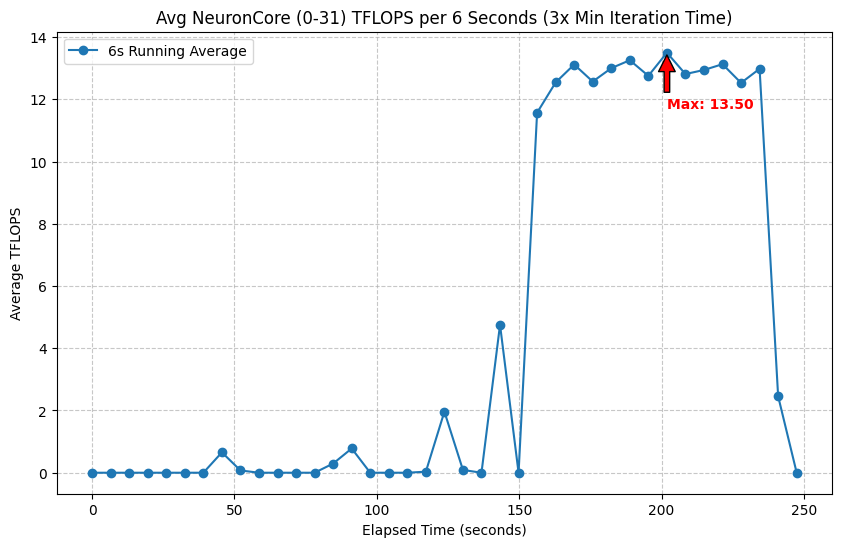

In [14]:
tflops(first_n=first_n)

Average Memory Max 12.379527296660081
-----Plotting-----


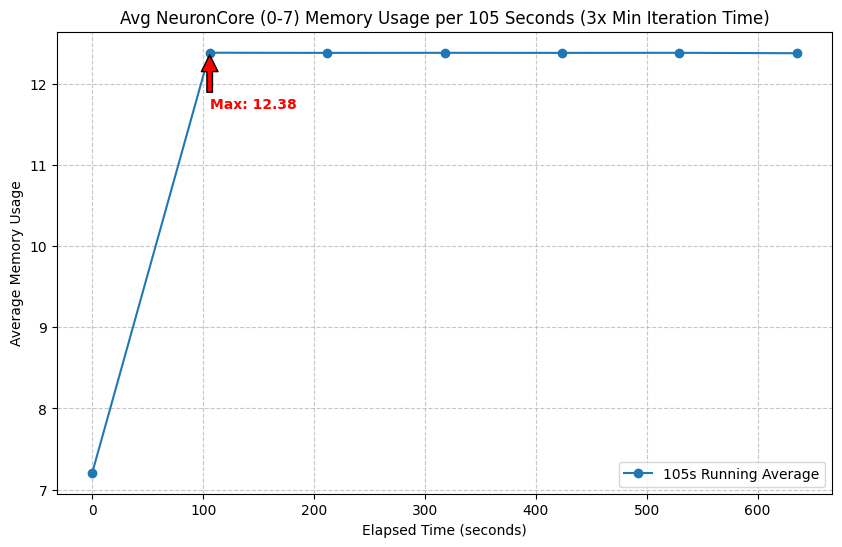

In [6]:
total_memory(first_n=first_n)


Average Constants Memory Max 1.159481942653656
-----Plotting-----


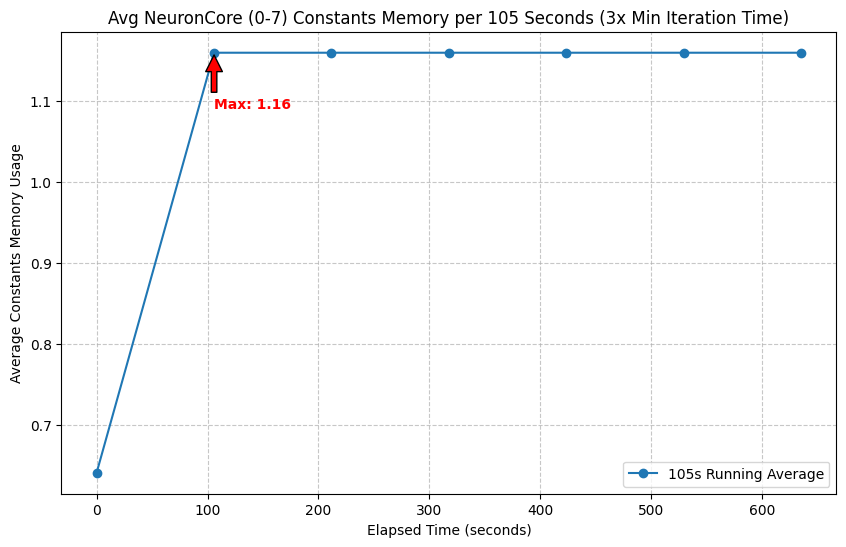

In [7]:
constantMem(first_n=first_n)

Average Tensors Memory Max 7.708712450738223
-----Plotting-----


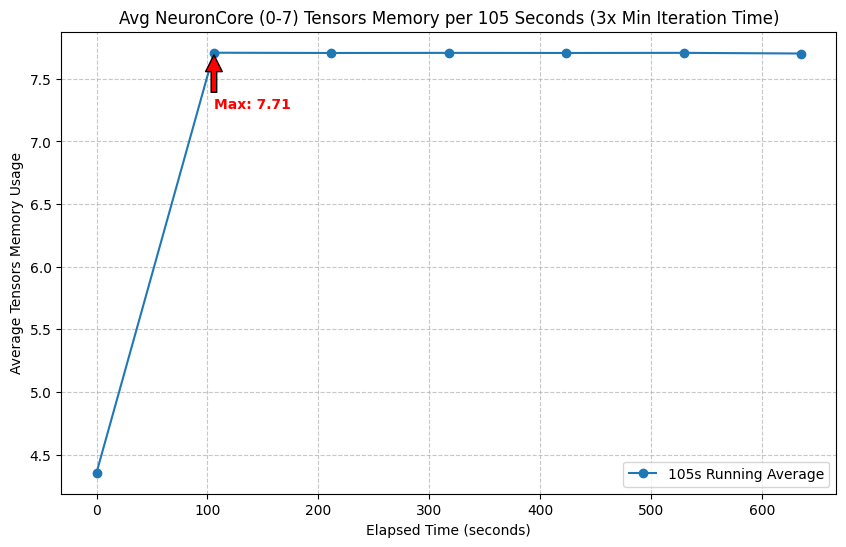

In [8]:
tensorMem(first_n=first_n)

Average Model_code Memory Max 0.7597453147172928
-----Plotting-----


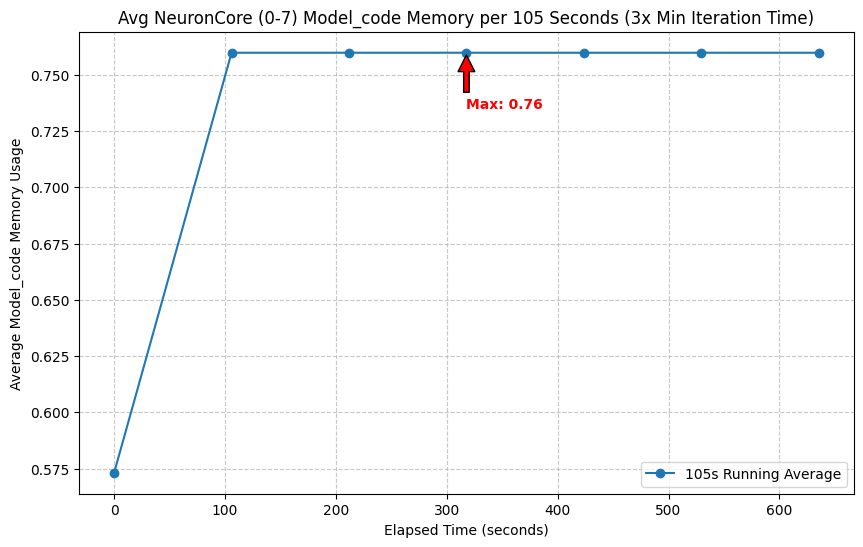

In [9]:
modelCodeMem(first_n=first_n)

Average Model_shared_scratchpad Memory Max 2.750000238418579
-----Plotting-----


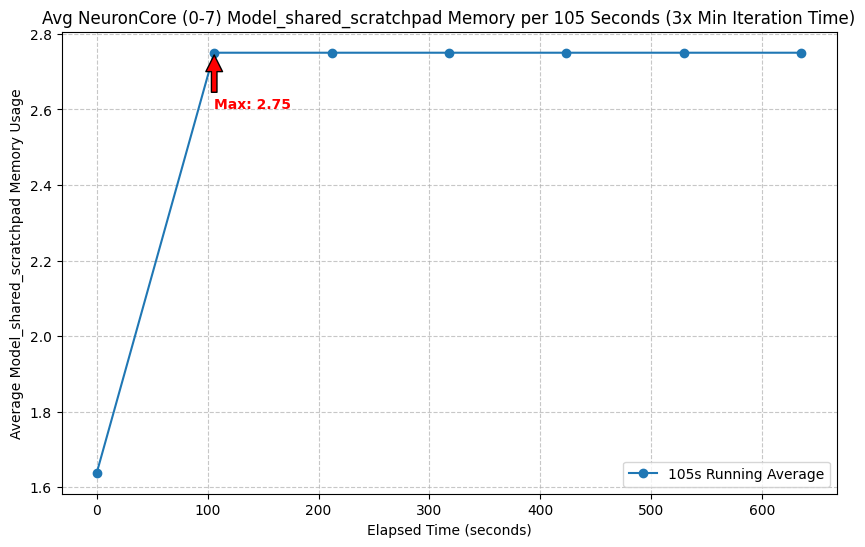

In [10]:
modelSharedScratchpadMem(first_n=first_n)

Average Runtime_memory Memory Max 0.001593127670996594
-----Plotting-----


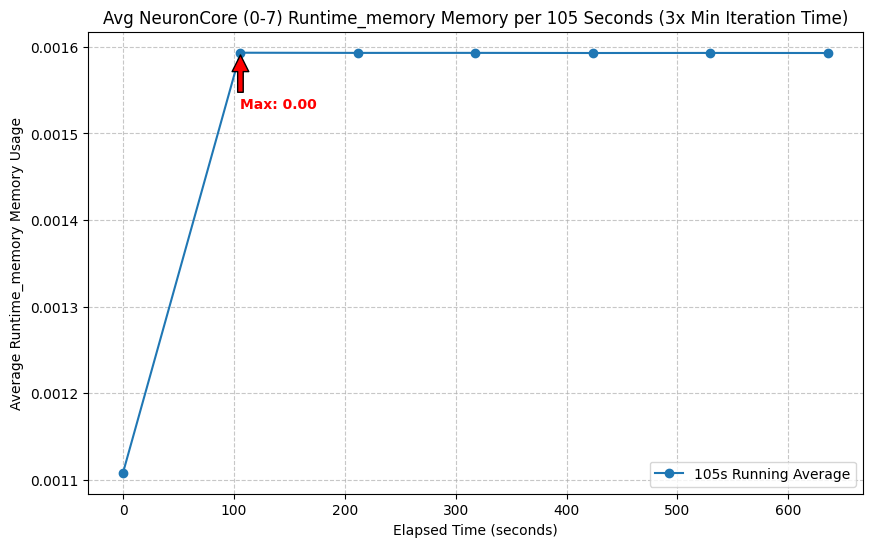

In [11]:
runtimeMem(first_n=first_n)

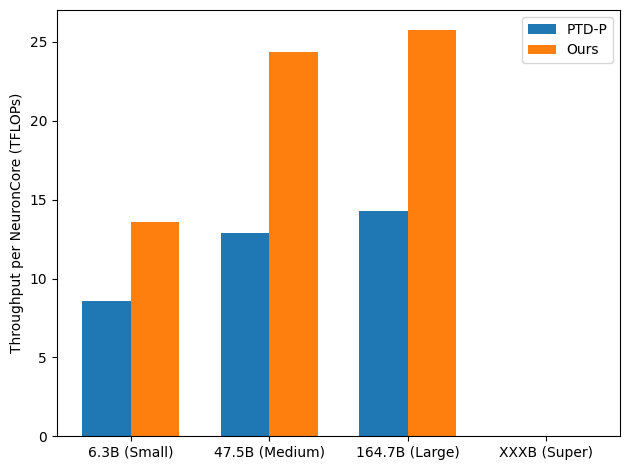

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 4 categories on the x-axis
categories = ["6.3B (Small)", "47.5B (Medium)", "164.7B (Large)", "XXXB (Super)"]

# Two bar-series (2 bars per category)
series1 = [8.56, 12.87, 14.27, 0]
series2 = [13.57, 24.35, 25.74, 0] 

x = np.arange(len(categories))   # [0,1,2,3]
width = 0.35                     # width of each bar

fig, ax = plt.subplots()

ax.bar(x - width/2, series1, width, label="PTD-P")
ax.bar(x + width/2, series2, width, label="Ours")

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Throughput per NeuronCore (TFLOPs)")
# ax.set_title("Grouped Bar Chart (4 categories, 2 bars each)")
ax.legend()

plt.tight_layout()
plt.show()
